<a href="https://colab.research.google.com/github/mib-a/AI-ML-Learning/blob/main/mib-a/AI-ML-Learning/Month-03-Deep-Learning/DL-Projects/01_MNIST_digit_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Deep Learning - Week 4 - Conceptual Session

## Dataset Overview

---
## Dataset Introduction:  
The MNIST dataset is a classic collection of 70,000 grayscale images of handwritten digits used to train and test machine learning models.

Key Details
- Total Images: 70,000 black-and-white pictures.
- Split: 60,000 training images and 10,000 testing images.
- Image Size: 28 by 28 pixels.

- Categories: Digits from 0 to 9.

- Creators: Yann LeCun, Corinna Cortes, and Christopher Burges.

---

## Dataset Analyzing:
- usntructured data (not tabular): iamge, text, speech.
- Goal: Train your model to recognise any hand written digit which is in grayscale.
- Multiclass Classification Problem (10 digits output layer - $0-9$)

### Image:
Image breaks down into matrix of pixels (28*28 for this datasets images) -> Pixels got assigned numbers according to their colors (0, 255)

- Grayscale Image:
  - 1D
  - pixel: black (0) and white (255) (0-255)
- RGB Image (Colorful):
  - 3D
  - pixel: every element of matrix gets 3 parts [R (0-255), G(0-255), B(0-255)]. So that pixel/element of the matrix will be the mixture of those 3 shades of RGB.
  - Why RGB? -> Fundamental colors of all colors.

## Work Flow
1. Understand the Goal : recognizing hand written numbers
2. Design the neural network
3. Implement
  - Dataset Loading (zip, .npy file)
  - Visialize
  - Train Test Split
  - Conversion (np -> tensor)
  - DataLoader
  - Architecture
    - sequential
    - Forward Pass
  - Loss and Graient Descnet
  - loop of epochs
  - prediction
  


### 0. Imporing Everything

In [36]:
import torch
import torch.nn as nn # will work with nn module
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


### 1. Loading the Dataset

The code block below has been copied and pasted from [Geeks for Geeks MNIST documentary](https://www.geeksforgeeks.org/machine-learning/mnist-dataset/$0) (recommended reading)

In [37]:
from tensorflow.keras.datasets import mnist # importing the dataset source # it will throw a yellow warning, ignore
import numpy as np

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print(f"Type of train_images: {type(train_images)} | Shape of train_images: {train_images.shape}") # 60000 samples, (28, 28): shape of each sample
print(f"Type of test_images: {type(train_labels)} | Shape of test_images: {test_images.shape}")
print(f"\ntrain_images's first sample's 14th row before scaling: {train_images[0][14]}")

# Scaling by dividing by the highest possible value of the element (255)
train_images = train_images / 255.0
print(f"\ntrain_images's first sample's 14th row after scaling: {train_images[0][14]}\n")
test_images = test_images / 255.0

Type of train_images: <class 'numpy.ndarray'> | Shape of train_images: (60000, 28, 28)
Type of test_images: <class 'numpy.ndarray'> | Shape of test_images: (10000, 28, 28)

train_images's first sample's 14th row before scaling: [  0   0   0   0   0   0   0   0   0   0   0   0   0  81 240 253 253 119
  25   0   0   0   0   0   0   0   0   0]

train_images's first sample's 14th row after scaling: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.31764706 0.94117647 0.99215686 0.99215686 0.46666667
 0.09803922 0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]



#### Accessing the matrices

In [38]:
# print(f"train_images's first sample's matrix: {train_images[0]}\n") # num of elements in that matrix: 28*28 = 784
print(f"Label of train_images's first sample: {train_labels[0]}") # what the photo if of train_images[0]
# The first line need to be uncommented while u are playing with the accessing part
print(f"Shape of train_images's first sample's matrix: {train_images[0].shape}")
print(f"length of train_images's first sample's first col's length: {len(train_images[0][:][0])}") # play with it a lil to understand the index better
print(f"train_images's 14th sample's 14th element: {train_images[0][14][14]}")


Label of train_images's first sample: 5
Shape of train_images's first sample's matrix: (28, 28)
length of train_images's first sample's first col's length: 28
train_images's 14th sample's 14th element: 0.9411764705882353


## Visualizing the Dataset

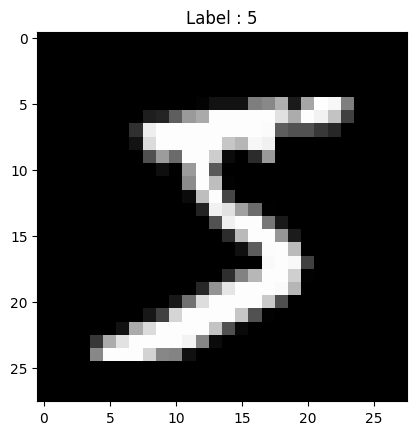

In [39]:
import matplotlib.pyplot as plt

plt.imshow(train_images[0] , cmap ='gray')
plt.title(f'Label : {train_labels[0]}')

plt.show()

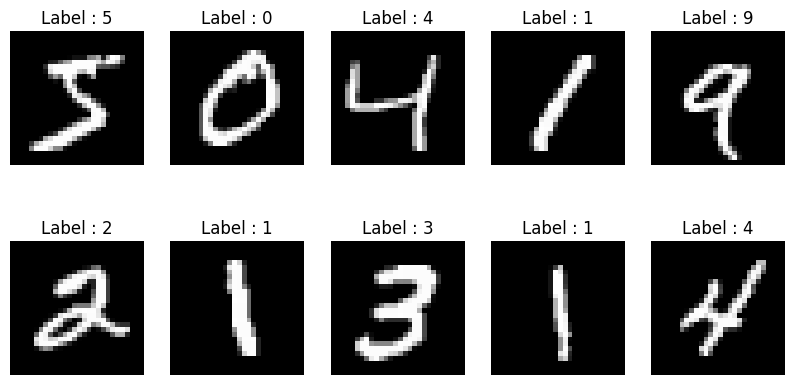

In [40]:
fig , axes = plt.subplots(2, 5 , # in one figure, there will be 2*5 subplots, 2 rows, 5 cols
                          figsize=(10,5)) # the width (col based distance) and the length (row based distance) of the figure
# to access axes
axes = axes.flatten()
for i in range(10):
  axes[i].imshow(train_images[i] , cmap='gray')
  axes[i].set_title(f'Label : {train_labels[i]}')
  axes[i].axis('off')

plt.show()



`axes = axes.flatten()` Explanation:

- 2D -> 1D conversion
- to access each element we needed `axes[0][0]` before, index range to 28, now all rows are flattened. so rows has become cols like: `[row-01][row-02]`; so now u can just say axes[0] to [784-1] to access all of them.
- If u don't want to use this method, u can use nested loop which is shown below.


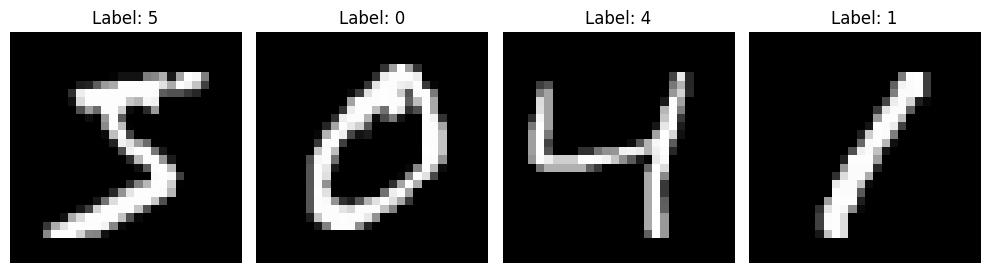

In [41]:
import matplotlib.pyplot as plt # for visualizing
plt.figure(figsize=(10, 3))
for i in range(4): # 0, 1, 2, 3 : total 4 samples
    plt.subplot(1, 4, i + 1) # subplot(row(=1), col(=4), index of the position: so it falls sequentially)
    plt.imshow(train_images[i], cmap="gray")
    plt.title(f"Label: {train_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Code Explanation:
```
i = 0
for loop activates
subplot(row 1, col 1, index 1)
shows train_images[0]
title fo that photo: train_labels[0]
```

## Train_Test Split
## Test Train and Validation Explanation:
We divide the dataset like this:
- **Train (TextBook)** : just studying, understanding the model : 60k (tts == 0.1)
  - **Valiidation (Mock Exam)**: testing where the gaps are, fine tuning the parameters; hence the architecture : 6k (10% or 0.1 of training samples)
- **Test (Board Exam)** : Strict Evaluation of model's performance : 10% of total data (70k*0.1 = 10k)

In [42]:
from sklearn.model_selection import train_test_split

# dividing the train images into 2 parts -> textbook studying (train) & mock exams (validation)
# all these are numpy array, so np in the name
X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(train_images, train_labels, test_size=0.1, random_state=42)


In [43]:
X_test_np = test_images
print(f"type of X_train_np: {type(X_train_np)} | shape of X_train_np: {X_train_np.shape}")
print(f"type of X_test_np: {type(X_test_np)} | shape of X_test_np: {X_test_np.shape}")

type of X_train_np: <class 'numpy.ndarray'> | shape of X_train_np: (54000, 28, 28)
type of X_test_np: <class 'numpy.ndarray'> | shape of X_test_np: (10000, 28, 28)


## Numpy to Tensor Conversion
As DataLoader can only be used in Tensor

In [44]:
# For Learning: Textbook
X_train = torch.tensor(X_train_np , dtype = torch.float32)
y_train = torch.tensor(y_train_np , dtype = torch.long) # long == 64 bit signed integer
# cross entropy prefers only long dtype for discrete class labels.

# For Tuning: Mock Exam
X_val = torch.tensor(X_val_np, dtype = torch.float32)
y_val = torch.tensor(y_val_np , dtype = torch.long)

# for Evaluating: Board Exam
X_test = torch.tensor(test_images , dtype = torch.float32)
y_test = torch.tensor(test_labels ,dtype = torch.long )

## Dataset Making and Loading

DataLoader: provides the datasets with this
- Batching: for mini batch gradient descent  
- Shuffling:
  - train dataset: automatically reshuffles data at every epoch so model can't memorize sample sequences thus prevents leakage and overfitting.
  - test dataset:
    - Zero Impact: As there is no backpropagation. So no repeated data. Model is only seeing them for the first time. So shuffling is unnecessary.
    - Error Analysis easier if the data are deterministic.
- Multiprocessing: CPU hardware stuffs (not sure)

#### Example of TensorDataset and DataLoader

In [45]:
# Dummy Dataset
features = torch.tensor([[1.0,2.0], [3.0,4.0] , [5.0,6.0]])
labels = torch.tensor([0,1,0])

dataset = TensorDataset(features, labels)
print(f"Integrating features and Labels together to make the dataset (2nd sample): {dataset[1]}\n") # integrating features and labels together


# dataloader
# you can change the num of batches and play urself
dataloader = DataLoader (dataset,
                         batch_size = 2, # 2 wil be processed each time (so total num of batches: 3/B = 1 batch of 2 samples and another batch of rest 1 sample)
                         shuffle = True) # batches are randomized/shuffled

for batch in dataloader : # batch = 2 here
  features , label = batch
  print("feature :", features)
  print("label :", label)

Integrating features and Labels together to make the dataset (2nd sample): (tensor([3., 4.]), tensor(1))

feature : tensor([[5., 6.],
        [1., 2.]])
label : tensor([0, 0])
feature : tensor([[3., 4.]])
label : tensor([1])


In [46]:
# making the 3 types of dataset, with the labels
train_dataset = TensorDataset(X_train,y_train)
val_dataset = TensorDataset(X_val,y_val)
test_dataset = TensorDataset(X_test,y_test)

# Putting them into DataLoader
train_loader = DataLoader(train_dataset, # the dataset it will work with
                          batch_size=64, # will pick 64 samples each time while working
                          shuffle = True) # the shuffle option of dataLoader; essential for training to prevent model from memorizing sample sequences with target

val_loader = DataLoader(val_dataset ,batch_size=64 , shuffle = False) # shuffle unnecessary
test_loader = DataLoader(test_dataset ,batch_size=64 , shuffle = False)

In train_loader, in each eposh, there will be $\frac{54000}{64} = 843.75$ batches in each epochs. And, in each batch 64 images.


## Architecture Modeling:
```
Input (784 elements)  
Layer-01:  (128 neurons)
Layer-02:  (64 neurons)
Output Layer:  (10 neurons: 0 t0 9)
```

Input Layer to Layer-01:
- Total numbers of elements: 28 * 28 = 784

Layer-01:
- Num of neurons: 128 (=outputs)
- Input: 28 * 28 = 784 elements
- Trainable Parameters: 784 * 128 (num of elements per sample, weights per sample for each neurons) + 128 (num of bias per neuron) = 100480
-  Num of outputs: 128 (each neuron will give one output)
- Forward Pass:
  - Linear Operation
  - Activation Function: ReLU (Rectified Linear Unit)
    - Fast Computation
    - Mitigating Vanishing Gradients: as relu only keeps numbers greater than zero, so vanishing gradient won't happen.

Layer-02:
- Num of neurons: 64 (=outputs)
- Input: 128 neuron's output (of first layer)
- Trainable Parameters: Layer-01 to Layer-02: 128 * 64 (weights) + 64 (biases) = 8256
- Num of Outputs: 64 (each neuron will yield one)
- ACT: ReLU - same reason

Output Layer:
- 10 neurons (0-9 range)
- trainable parameters: 64*10 + 10 = 650
- ACT: ReLU - should use SoftMaz but the dataset is incredibly easy, so ReLU will work too.




In [47]:
class DigitClassificationModel(nn.Module): # model_name (importin nn module)
  def __init__(self , input_size, num_classes): # building the constructor
    super().__init__() # involvement: nn module attributes

    # Building the network by using sequential
    self.network = nn.Sequential(
        nn.Flatten(), # same reason as it was explained in axes
        # nn.Linear(input_size, output_size)
        nn.Linear(input_size, 128 ), # 1st layer: 128 neurons
        nn.ReLU(), # 1st layer ACT
        nn.Linear(128, 64), # 2nd layer: 64 neuron
        nn.ReLU(), # 2nd layer ACT
        nn.Linear(64, num_classes) # Output layer
    )

  # Forward Pass
  def forward(self , features):
    output = self.network(features)
    return output

In [48]:
# training the modek
model =  DigitClassificationModel(input_size = 28*28 , num_classes=10)
print(model)

DigitClassificationModel(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


## Loss & Gradient Descent

In [49]:
# for optimization; as all w & b values are randomized so will get garbage prediction (it will be optimized by this)
import torch.optim as optim
criterion = nn.CrossEntropyLoss() # loss fn is stored in criterion by convention in research
# Note: SoftMax ACT can't calculate Cross Entropy Loss
optimizer = optim.SGD(model.parameters(), # optimize Stochastic Gradient Descent of the parameters of the model
                      lr= 0.01) # learning rate
print(optimizer) # viewing the optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


## Loop to develop it

In [50]:
epochs = 10 # declaring the epoch

# Setting up the Epoch
for epoch in range(epochs):
  running_loss = 0.0 # so epoch 2 doesnt carry the loss of epoch 1 and so on...

# Training Loop : Batch Processing
  for images,labels in train_loader : # looping through each batch
    optimizer.zero_grad() # gradient zero so prev gradient calculations don't ruin it
    outputs = model(images) # geenrating prediction through using the model (forward pass)

    loss = criterion(outputs,labels ) # calculating error between output predicition and labels
    loss.backward() # calculating the gradient descents per batch
    optimizer.step() # optimizing == updating the parameters
    running_loss+= loss.item() # collect loss for each batches and sums it up for that specific epoch

  val_loss = 0.0 # declaring validation loss = 0 at the beginning of each epochs

  with torch.no_grad(): # validation data doesn't need backpropagation so off
    # looping process same as before without the loss.backward and optimizer.step() lines
    for images,labels in val_loader :
      outputs = model(images)
      loss = criterion(outputs,labels)
      val_loss+= loss.item()

  print(f'Epoch {epoch+1}/ {epochs} | Train Loss : {running_loss:.4f} | Validation Loss: {val_loss:.4f}'
  )


Epoch 1/ 10 | Train Loss : 1662.4671 | Validation Loss: 108.0394
Epoch 2/ 10 | Train Loss : 600.0889 | Validation Loss: 48.2985
Epoch 3/ 10 | Train Loss : 379.5435 | Validation Loss: 37.7165
Epoch 4/ 10 | Train Loss : 321.4690 | Validation Loss: 33.5677
Epoch 5/ 10 | Train Loss : 290.6495 | Validation Loss: 30.5118
Epoch 6/ 10 | Train Loss : 268.5669 | Validation Loss: 28.4044
Epoch 7/ 10 | Train Loss : 251.2756 | Validation Loss: 26.7334
Epoch 8/ 10 | Train Loss : 236.0214 | Validation Loss: 25.4276
Epoch 9/ 10 | Train Loss : 222.8497 | Validation Loss: 24.0315
Epoch 10/ 10 | Train Loss : 210.9905 | Validation Loss: 22.7027


## Prediction

#### Argmax

In [51]:
# A little about argmax
torch.argmax(torch.tensor([[9, 10, 942, 24, 42]]), dim=1)

# prints out the index which holds the biggest number

tensor([2])

In [52]:
with torch.no_grad(): # same reason as validation
  y_pred_prob = model(X_test)

# print(y_pred_prob.shape) # -> (10000, 10) # 10 cols for each numbers (0-9)
print(f"first row of prediction: {y_pred_prob[0][:]}")
print(f"The index with the highest value here is : {torch.argmax(y_pred_prob[0][:])}")
print(f"So, the first predicted number will be: {torch.argmax(y_pred_prob[0][:])}")

# Index in Tensor ~= Assigned class label, y_pred is the raw score we all are melting for
y_pred = torch.argmax(y_pred_prob ,dim = 1) # per row which index holds the biggest probability.

print("\nPrediction: ", y_pred[:10])
print("Actual:", y_test[:10])

first row of prediction: tensor([ 1.4065, -4.8243,  3.3850,  4.8305, -4.6766,  1.5805, -9.7438, 10.4654,
        -0.3928,  3.1580])
The index with the highest value here is : 7
So, the first predicted number will be: 7

Prediction:  tensor([7, 2, 1, 0, 4, 1, 4, 9, 6, 9])
Actual: tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])
